In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import ( mean_absolute_error , mean_squared_error , root_mean_squared_error , r2_score )

In [2]:
df = pd.read_csv("boston.csv")
df.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   CRIM        506 non-null    float64
 2   ZN          506 non-null    float64
 3   INDUS       506 non-null    float64
 4   CHAS        506 non-null    float64
 5   NOX         506 non-null    float64
 6   RM          506 non-null    float64
 7   AGE         506 non-null    float64
 8   DIS         506 non-null    float64
 9   RAD         506 non-null    float64
 10  TAX         506 non-null    float64
 11  PTRATIO     506 non-null    float64
 12  B           506 non-null    float64
 13  LSTAT       506 non-null    float64
 14  Price       506 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 59.4 KB


In [7]:
df.describe()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,252.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,126.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,252.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,378.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,505.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [9]:
df.isnull().sum()

Unnamed: 0    0
CRIM          0
ZN            0
INDUS         0
CHAS          0
NOX           0
RM            0
AGE           0
DIS           0
RAD           0
TAX           0
PTRATIO       0
B             0
LSTAT         0
Price         0
dtype: int64

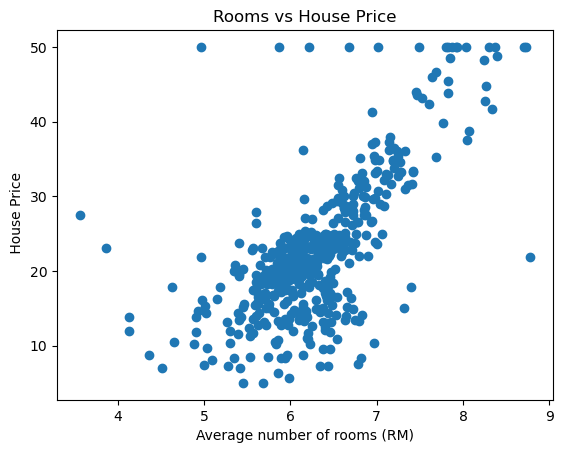

In [11]:
plt.scatter(df['RM'], df['Price'])
plt.xlabel("Average number of rooms (RM)")
plt.ylabel(" House Price")
plt.title("Rooms vs House Price")
plt.show()

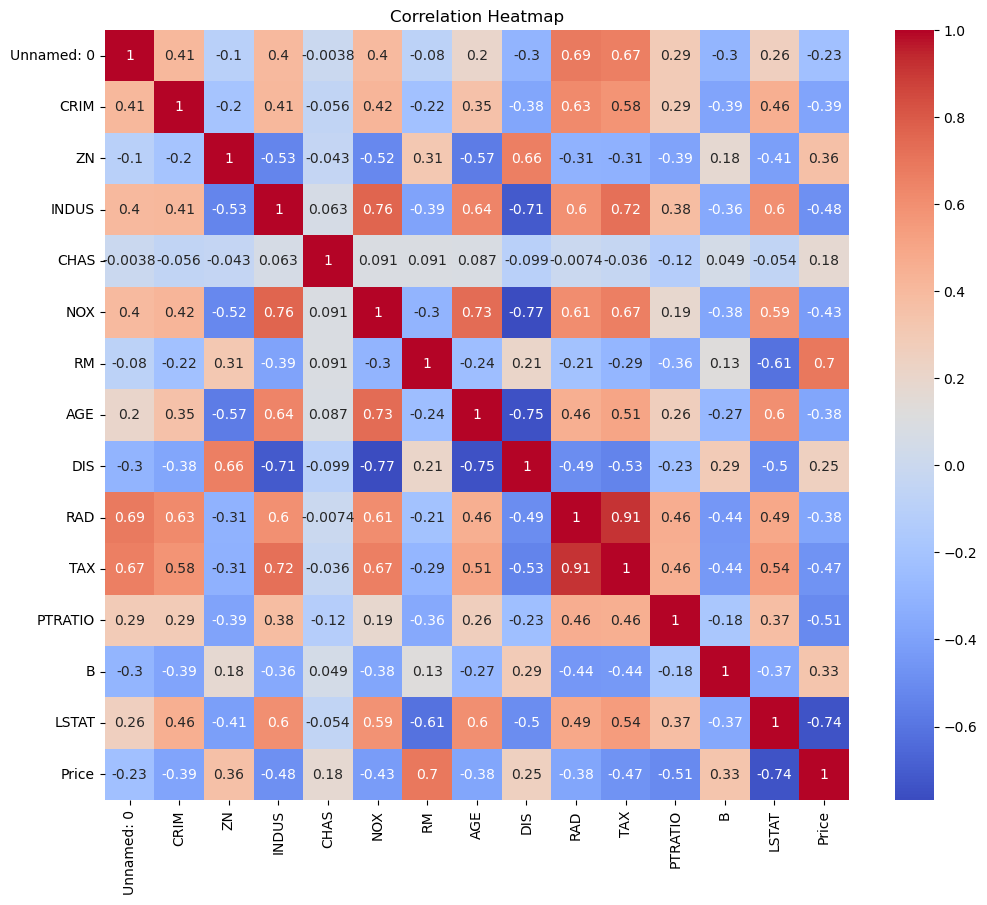

In [13]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True , cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [15]:
# Feature Selection
x = df.drop("Price",axis=1)
y = df['Price']

In [17]:
# Train and Test Split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [19]:
# Feature Scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [21]:
# Now we will train the model
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [23]:
## predictions

y_pred = model.predict(x_test)
y_pred

array([28.97335364, 35.87795794, 13.97366183, 25.61583978, 18.66608153,
       23.64466022, 17.05971239, 14.5264485 , 22.79402759, 19.60618783,
       24.62043501, 19.06428675, -6.27197735, 22.20788474, 18.64849181,
       26.15022718, 20.62835191,  5.77374284, 40.72117979, 17.48530737,
       27.08436097, 29.90818637, 11.65330429, 22.99879937, 17.85048447,
       15.5556251 , 23.31650588, 14.44013189, 22.11106256, 18.20109763,
       22.33391113, 24.79774986, 26.15304018, 17.89425941, 16.52927207,
       17.10592481, 31.77372627, 19.58243073, 23.603617  , 25.2202457 ,
       12.89702838, 31.91216634, 42.90231353, 17.74616574, 27.5000776 ,
       17.06259552, 14.39460992, 26.51167547, 20.10908837, 30.51587021,
       21.74636797, 34.09117218, 16.44234996, 26.62572161, 39.42027423,
       22.49131562, 18.75511558, 32.62323592, 25.35325167, 12.58127149,
       23.23090959, 31.15654212, 31.70938821, 16.555899  , 19.75136599,
       16.30198537, 20.60703158, 26.4253367 , 31.3483927 , 11.44

In [25]:
## Model Evaluation
mae = mean_absolute_error(y_test , y_pred)
mse = mean_squared_error(y_test , y_pred)
rmse = root_mean_squared_error(y_test , y_pred)
r2 = r2_score(y_test , y_pred)
print("Mean Absolute Error : ", mae)
print("Mean Squared Error : ", mae)
print("Root Mean Squared Error : ", mae)
print("R2 S", mae)

Mean Absolute Error :  3.2007547573408206
Mean Squared Error :  3.2007547573408206
Root Mean Squared Error :  3.2007547573408206
R2 S 3.2007547573408206


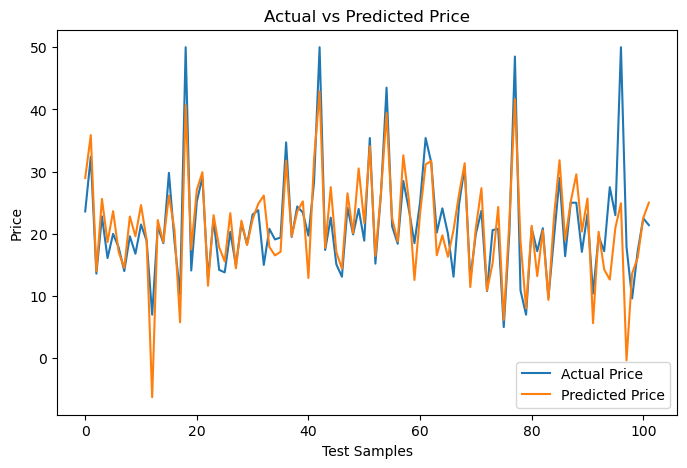

In [27]:
# Actual vs Predicted Graph
plt.figure(figsize=(8,5))
plt.plot(y_test.values, label = "Actual Price")
plt.plot(y_pred , label = "Predicted Price")
plt.legend()
plt.title("Actual vs Predicted Price")
plt.xlabel("Test Samples")
plt.ylabel("Price")
plt.show()

In [32]:
#Predict the price of the first house in the test set
sample = x_test[0].reshape(1, -1)
predicted_price = model.predict(sample)
print("Predicted House Sample : " , predicted_price[0])
print("ACtual House Price : " , y_test.iloc[0])

Predicted House Sample :  28.973353639142367
ACtual House Price :  23.6
